# De beaux graphiques avec python : mise en pratique

Lino Galiana  
2024-08-09

La pratique de la visualisation se fera, dans ce cours, en répliquant des graphiques qu’on peut trouver sur
la page de l’*open data* de la ville de Paris
[ici](https://opendata.paris.fr/explore/dataset/comptage-velo-donnees-compteurs/dataviz/?disjunctive.id_compteur&disjunctive.nom_compteur&disjunctive.id&disjunctive.name).

Ce TP vise à initier :

-   Aux packages [`matplotlib`](https://matplotlib.org/) et
    [`seaborn`](https://seaborn.pydata.org/) pour la construction de graphiques figés. Il
    est également possible de s’appuyer sur [`plotnine`](https://plotnine.readthedocs.io/en/stable/index.html),
    qui est une implémentation en `Python` du *package* `R` [`ggplot2`](https://ggplot2.tidyverse.org/)
    pour ce type de représentation.
-   Au package [`plotly`](https://plotly.com/python/) pour les graphiques
    dynamiques, au format *web*

Nous verrons par la suite la manière de construire des cartes facilement avec
des formats équivalents.

Si vous êtes intéressés par `R` ,
une version très proche de ce TP est
disponible dans [ce cours d’introduction à `R` pour l’ENS](https://rgeo.linogaliana.fr/exercises/ggplot.html).

<div class="alert alert-info" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-comment"></i> Note</h3>

Être capable de construire des visualisations de données
intéressantes est une compétence nécessaire à tout
*data scientist* ou chercheur. Pour améliorer
la qualité de ces visualisations, il est recommandé
de suivre certains conseils donnés par des spécialistes
de la *dataviz* sur la sémiologie graphique.

Les bonnes visualisations de données, comme celles du *New York Times*,
reposent certes sur des outils adaptés (des librairies `JavaScript`)
mais aussi sur certaines règles de représentation qui permettent
de comprendre en quelques secondes le message d’une visualisation.

Ce [post de blog](https://blog.datawrapper.de/text-in-data-visualizations/)
est une ressource qu’il est utile de consulter régulièrement.
Ce [post de blog d’Albert Rapp](https://albert-rapp.de/posts/ggplot2-tips/10_recreating_swd_look/10_recreating_swd_look) montre bien comment construire graduellement une bonne visualisation
de données.

</div>

# 1. Données

Un sous-ensemble des données de [Paris *Open Data*](https://opendata.paris.fr/explore/dataset/comptage-velo-donnees-compteurs/information/?disjunctive.id_compteur&disjunctive.nom_compteur&disjunctive.id&disjunctive.name) a été mis à disposition
pour faciliter l’import.
Il s’agit d’une extraction, qui commence à dater, des données disponibles
sur le site où seules les colonnes
qui servent à cet exercice ont été conservées.

# 2. Premières productions graphiques avec l’API `Matplotlib` de `Pandas`

Chercher à produire une visualisation parfaite du premier coup est
illusoire. Il est beaucoup plus réaliste d’améliorer graduellement
une représentation graphique afin, petit à petit, de mettre en
avant les effets de structure dans un jeu de données.

Nous allons donc commencer par nous représenter la distribution
des passages aux principales stations de mesure.
Pour cela nous allons produire
rapidement un *barplot* puis l’améliorer graduellement.

Dans cette partie, nous allons ainsi
reproduire les deux premiers graphiques de la
[page d’analyse des données](https://opendata.paris.fr/explore/dataset/comptage-velo-donnees-compteurs/dataviz/?disjunctive.id_compteur&disjunctive.nom_compteur&disjunctive.id&disjunctive.name) :
*Les 10 compteurs avec la moyenne horaire la plus élevée* et *Les 10 compteurs ayant comptabilisé le plus de vélos*. Les valeurs chiffrées des graphiques seront différentes de celles de la page en ligne, c’est normal, nous travaillons sur des données plus anciennes.

<div class="alert alert-success" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-pencil"></i> Exercice 1 : Importer les données et produire un premier graphique</h3>

Les données comportent plusieurs dimensions pouvant faire l’objet d’une
analyse statistique. Il est donc nécessaire dans un premier temps
de synthétiser celles-ci par des agrégations afin d’avoir un
graphique lisible.

1.  Importer les données de compteurs de vélos. Vous pouvez utiliser l’url <https://minio.lab.sspcloud.fr/projet-formation/diffusion/python-datascientist/bike.csv>.

<details>

<summary>

⚠️ Warning sur le format de données

</summary>

Il s’agit de données
compressées au format `gzip`, il faut donc utiliser l’option `compression = 'gzip'`

</details>

1.  Garder les dix bornes à la moyenne la plus élevée.
    Comme pour obtenir un graphique ordonné du plus grand au plus petit,
    il faut avoir les données ordonnées du plus petit au
    plus grand (oui c’est bizarre mais c’est comme ça…), réordonner
    les données ;

2.  En premier lieu, sans se préoccuper des éléments de style ni de la beauté
    du graphique, créer la structure du *barplot* (diagramme en batons) de la
    [page d’analyse des données](https://opendata.paris.fr/explore/dataset/comptage-velo-donnees-compteurs/dataviz/?disjunctive.id_compteur&disjunctive.nom_compteur&disjunctive.id&disjunctive.name).

3.  Pour préparer le travail sur la deuxième figure, ne conserver
    que les 10 compteurs ayant comptabilisés le plus de vélos

4.  Comme pour la question 3, créer un *barplot*
    pour reproduire la figure 2 de l’*open data* parisien

</div>

<details>
<summary>
Premières lignes nécessaires pour cet exercice :
</summary>

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>

|     | Identifiant du compteur | Nom du compteur                   | Identifiant du site de comptage | Nom du site de comptage           | Comptage horaire | Date et heure de comptage | Date d'installation du site de comptage |
|-----|-------------------------|-----------------------------------|---------------------------------|-----------------------------------|------------------|---------------------------|-----------------------------------------|
| 0   | 100003096-SC            | 97 avenue Denfert Rochereau SO-NE | 100003096                       | 97 avenue Denfert Rochereau SO-NE | 1                | 2019-08-01T02:00:00Z      | 2012-02-22                              |
| 1   | 100003096-SC            | 97 avenue Denfert Rochereau SO-NE | 100003096                       | 97 avenue Denfert Rochereau SO-NE | 0                | 2019-08-01T01:00:00Z      | 2012-02-22                              |
| 2   | 100003096-SC            | 97 avenue Denfert Rochereau SO-NE | 100003096                       | 97 avenue Denfert Rochereau SO-NE | 0                | 2019-08-01T04:00:00Z      | 2012-02-22                              |

</div>

</details>

<details>
<summary>
Les 10 principales stations à l'issue de la question 2
</summary>

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>

|                                    | Comptage horaire |
|------------------------------------|------------------|
| Nom du compteur                    |                  |
| 26 boulevard de Ménilmontant SE-NO | 109.462847       |
| 35 boulevard de Menilmontant NO-SE | 117.180643       |
| 21 boulevard Saint Michel S-N      | 117.730884       |
| 67 boulevard Voltaire SE-NO        | 119.208018       |
| 72 boulevard Voltaire NO-SE        | 124.391365       |

</div>

</details>

<details>
<summary>
Figure 1 sans travail sur le style:
</summary>

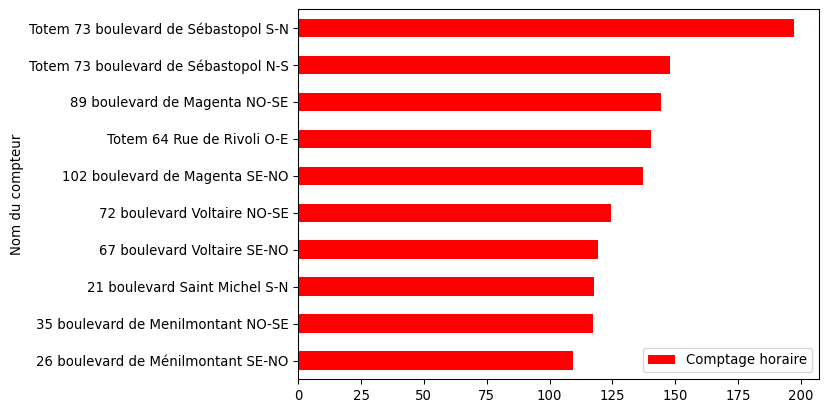

</details>

<details>
<summary>
Figure 2 sans travail sur le style:
</summary>

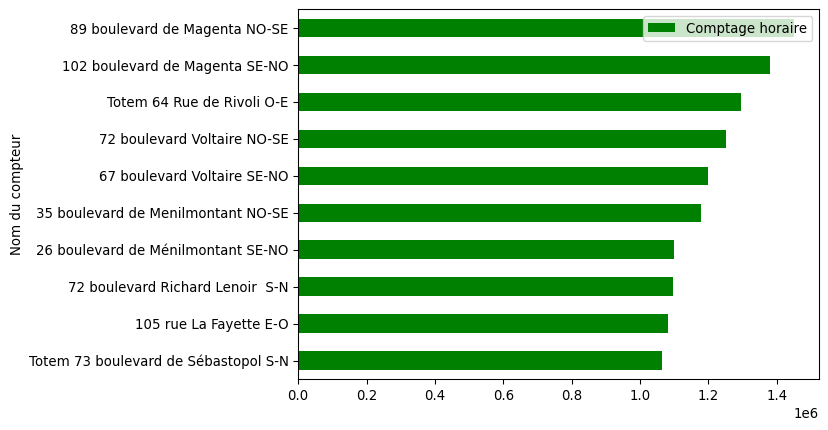

</details>

On commence à avoir quelque chose qui commence à transmettre
un message synthétique sur la nature des données.
On peut néanmoins remarquer plusieurs éléments problématiques
(par exemple les labels) mais
aussi des éléments ne correspondant pas (les titres des axes, etc.) ou
manquants (le nom du graphique…).

Comme les graphiques produits par `Pandas` suivent la logique très flexible
de `matplotlib`, il est possible de les customiser. Cependant, c’est
souvent beaucoup de travail et la grammaire `matplotlib` n’est
pas aussi normalisée que celle de `ggplot` en `R`.
Il peut être préférable de directement
utiliser `seaborn`, qui offre quelques arguments prêts à l’emploi.

# 3. Utiliser directement `seaborn`

Vous pouvez repartir des deux dataframes précédents. On va supposer qu’ils se
nomment `df1` et `df2`.

La figure comporte maintenant un message mais il est encore peu
lisible. Il y a plusieurs manières de faire un *barplot* en `seaborn`. Les deux principales
sont :

-   `sns.catplot` ;
-   `sns.barplot`.

On propose d’utiliser `sns.catplot` pour cet exercice.

<div class="alert alert-success" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-pencil"></i> Exercice 2 : Un peu de style !</h3>

1.  Réinitialiser l’index des *dataframes* `df1` et `df2`
    pour avoir une colonne *‘Nom du compteur’*. Réordonner les données
    de manière décroissante pour obtenir un graphique ordonné dans
    le bon sens avec `seaborn`.

2.  Refaire le graphique précédent avec la fonction `catplot` de `seaborn`. Pour
    contrôler la taille du graphique vous pouvez utiliser les arguments `height` et
    `aspect`.

3.  Ajouter les titres des axes et le titre du graphique pour le premier graphique

4.  Essayez de colorer en rouge l’axe des `x`. Vous pouvez pré-définir un
    style avec `sns.set_style("ticks", {"xtick.color": "red"})`

</div>

A l’issue de la question 2, c’est-à-dire en utilisant
`seaborn` pour reproduire de manière minimale
un *barplot*, on obtient :

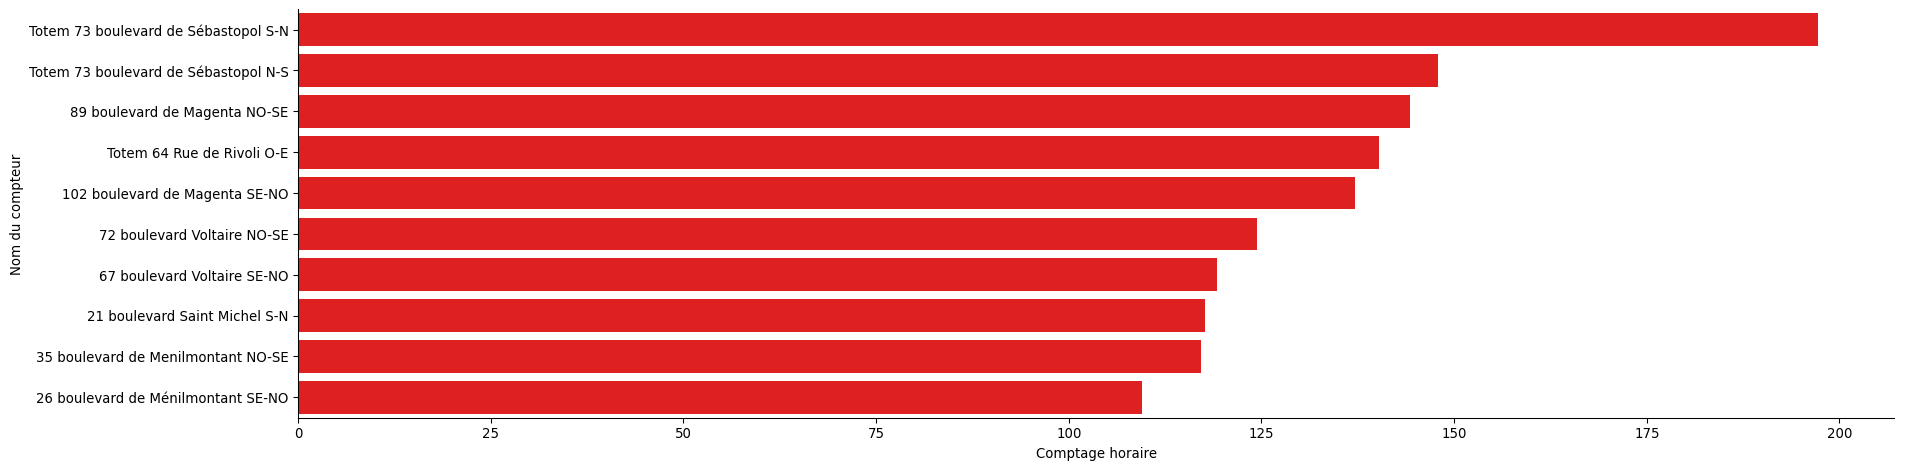

Après quelques réglages esthétiques, à l’issue des questions 3 et 4,
on obtient une figure proche de celle de l’*open data* parisien.

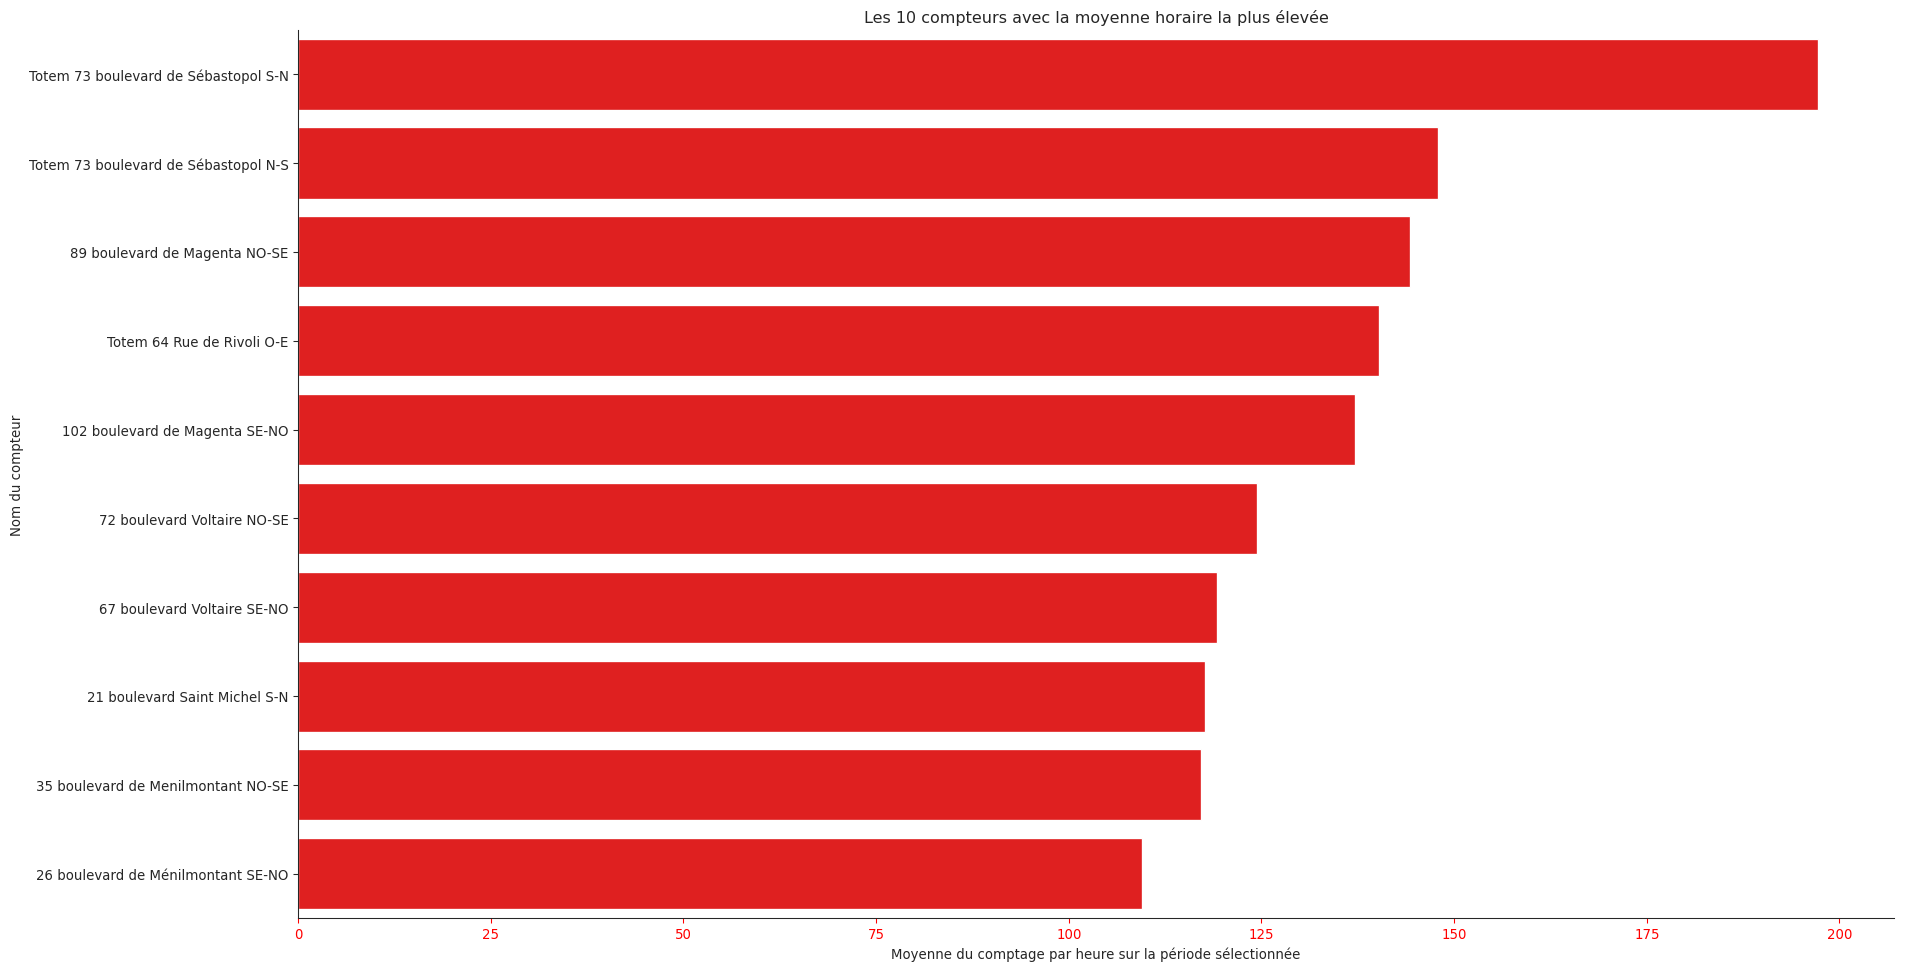

On comprend
ainsi que le boulevard de Sébastopol est le plus emprunté,
ce qui ne vous suprendra pas si vous faites du vélo à Paris.
Néanmoins, si vous n’êtes pas familiers avec la géographie parisienne,
cela sera peu informatif pour vous, vous allez avoir besoin d’une
représentation graphique supplémentaire: une carte ! Nous verrons
ceci lors d’un prochain chapitre.

<div class="alert alert-success" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-pencil"></i> Exercice 3 : reproduire la figure 2</h3>

En suivant l’approche graduelle de l’exercice 2,
refaire le graphique *Les 10 compteurs ayant comptabilisé le plus de vélos*.

</div>

Les diagrammes en batons (*barplot*) sont extrêmement communs mais
qu’ils transmettent. Sur le plan sémiologique,
les *lollipop charts* sont préférables : ils
transmettent la même information mais avec moins de bruit
(la largeur des barres du barplot noie un peu l’information).

<div class="alert alert-success" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-pencil"></i> Exercice 3 (bis) : reproduire la figure 2 avec un <i>lollipop chart</i></h3>

En suivant l’approche graduelle de l’exercice 2,
refaire le graphique *Les 10 compteurs ayant comptabilisé le plus de vélos*.

</div>

Text(0, 0.5, 'La somme des vélos comptabilisés sur la période sélectionnée')

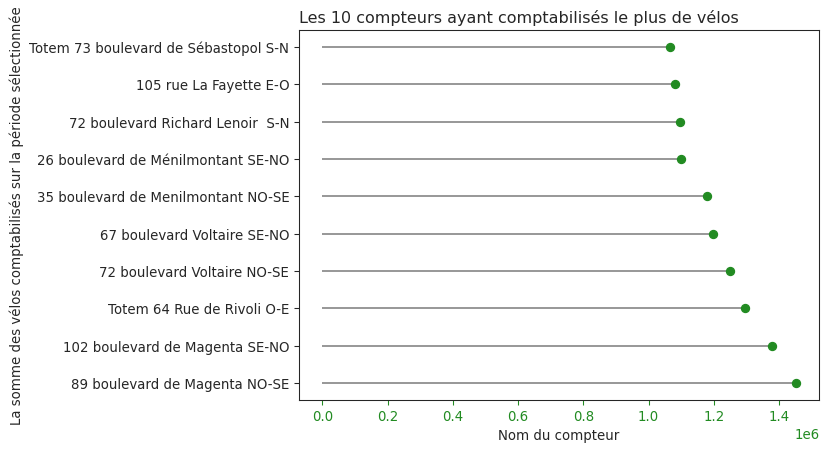

# 4. Premières agrégations temporelles

On va maintenant se concentrer sur la dimension spatiale de notre
jeu de données à travers deux approches :

-   Un diagramme en barre synthétisant l’information de notre jeu de données
    de manière mensuelle ;
-   Des séries instructives sur la dynamique temporelle. Cela sera l’objet de la prochaine partie.

Pour commencer, reproduisons la troisième figure qui est, encore une fois,
un *barplot*. La première question implique une première rencontre avec
une donnée temporelle à travers une opération assez classique en séries
temporelles : changer le format d’une date pour pouvoir faire une agrégation
à un pas de temps plus large.

<div class="alert alert-success" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-pencil"></i> Exercice 4: barplot des comptages mensuels</h3>

1.  Utiliser `to_datetime` du package `Pandas` pour transformer la variable `Date et heure de comptage`
    en horodatage car le type de celle-ci a été mal interprété à la lecture du fichier.
    Le format à utiliser est `%Y-%m-%dT%H:%M:%SZ`. Il peut être nécessaire d’utiliser également l’option `errors='coerce'`
2.  Créer une variable `month`
    dont le format respecte, par exemple, le schéma `2019-08` grâce à la bonne option de la méthode `dt.to_period`
3.  Appliquer les conseils précédents pour construire et améliorer
    graduellement un graphique afin d’obtenir une figure similaire
    à la 3e production sur la page de l’*open data* parisien.
4.  Question optionnelle: représenter la même information sous forme de *lollipop*

</div>

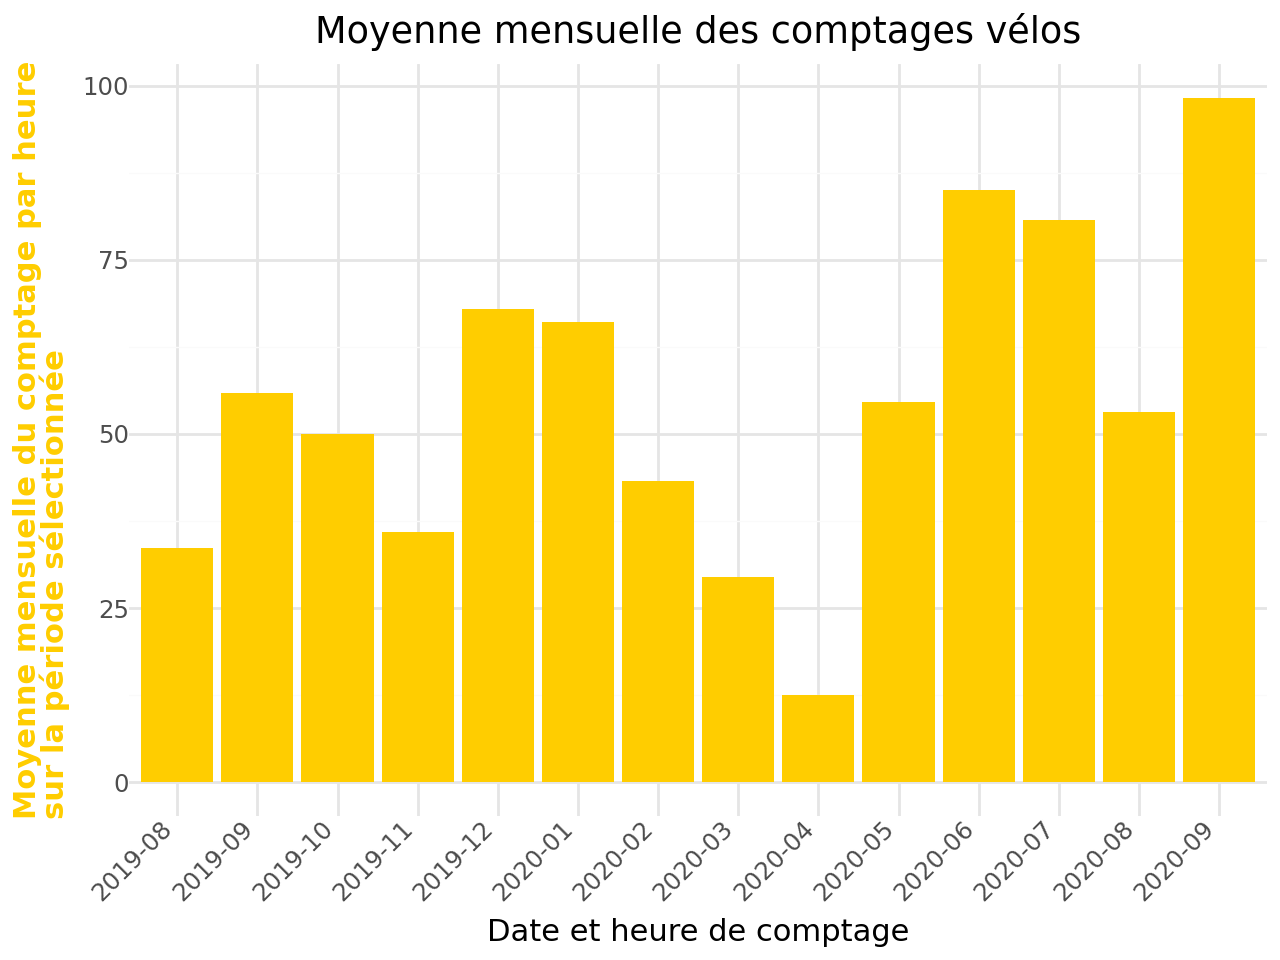

Si vous préférez représenter cela sous forme de *lollipop*[1]:

[1] J’ai retiré la couleur sur l’axe des ordonnées qui, je trouve,
apporte peu à la figure voire dégrade la compréhension du message.

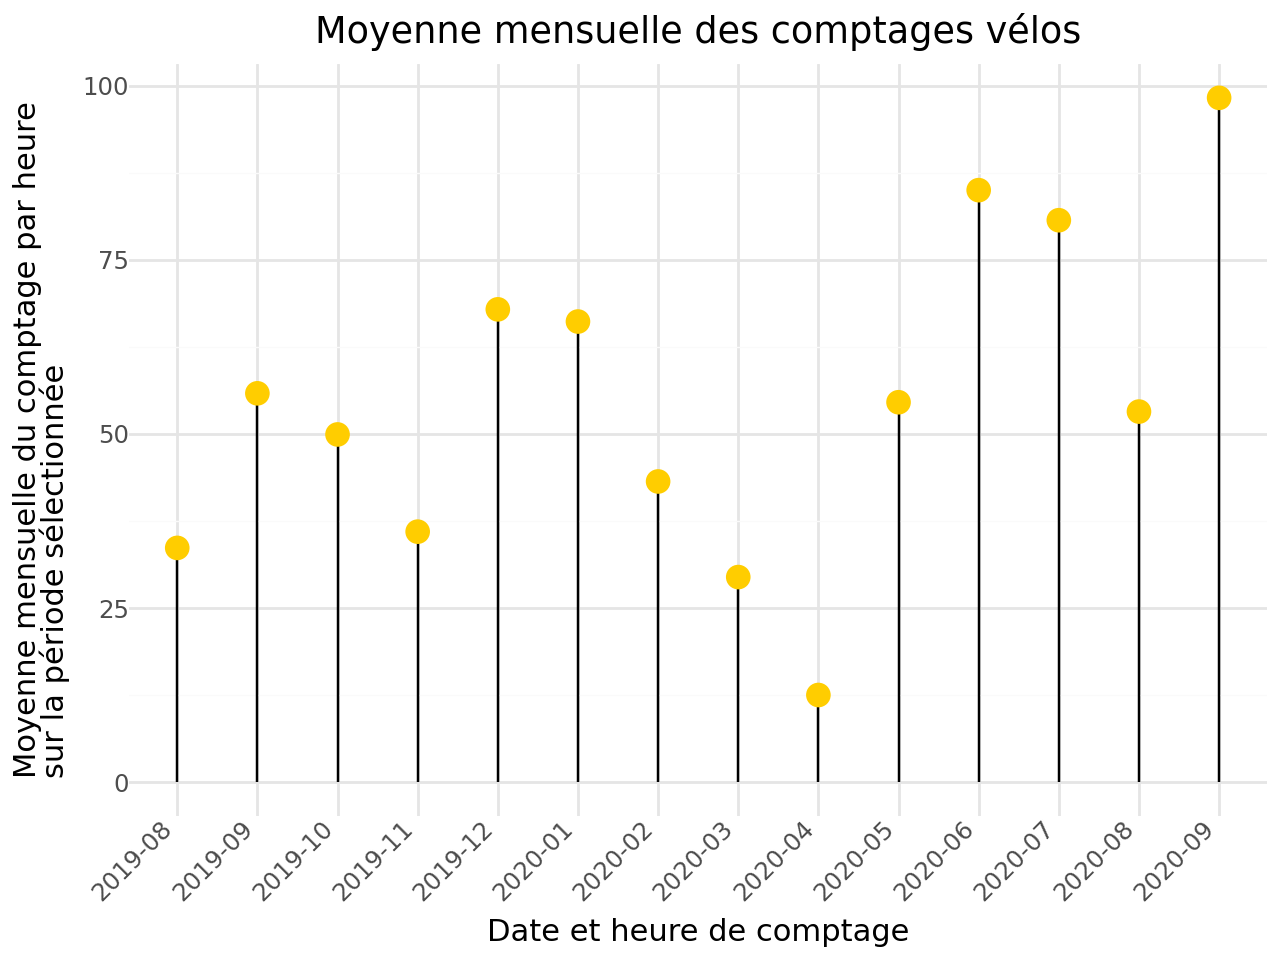

# 5. Première série temporelle

Il est plus commun de représenter sous forme de série
les données ayant une dimension temporelle.

<div class="alert alert-success" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-pencil"></i> Exercice 5: barplot des comptages mensuels</h3>

1.  Créer une variable `day` qui transforme l’horodatage en format journalier
    du type `2021-05-01` avec `dt.day`.
2.  Reproduire la figure de la page d’*open data*

</div>

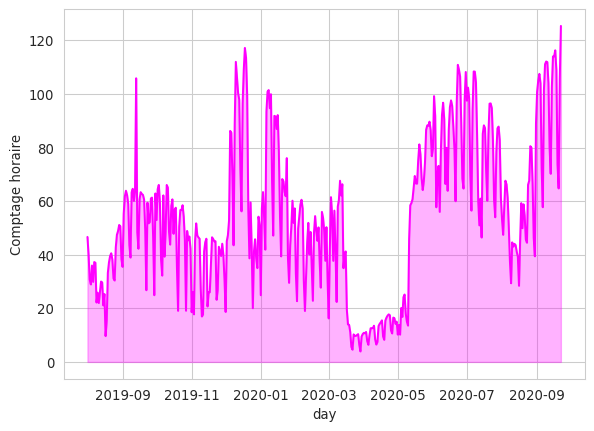

# 6. Des graphiques dynamiques avec `Plotly`

## 6.1 Contexte

L’inconvénient des figures avec `ggplot` est que celles-ci ne permettent
pas d’interaction avec le lecteur. Toute l’information doit donc être
contenue dans la figure ce qui peut la rendre difficile à lire.
Si la figure est bien faite, avec différents niveaux d’information, cela
peut bien fonctionner.

Il est néanmoins plus simple, grâce aux technologies *web*, de proposer des
visualisations à plusieurs niveaux. Un premier niveau d’information, celui du
coup d’oeil, peut suffire à assimiler les principaux messages de la
visualisation. Ensuite, un comportement plus volontaire de recherche
d’information secondaire peut permettre d’en savoir plus. Les visualisations
réactives, qui sont maintenant la norme dans le monde de la *dataviz*,
permettent ce type d’approche : le lecteur d’une visualisation peut passer
sa souris à la recherche d’information complémentaire (par exemple les
valeurs exactes) ou cliquer pour faire apparaître des informations complémentaires
sur la visualisation ou autour.

Ces visualisations reposent sur le même triptyque que l’ensemble de l’écosystème
*web* : `HTML`, `CSS` et `JavaScript`. Les utilisateurs de `Python`
ne vont jamais manipuler directement ces langages, qui demandent une
certaine expertise, mais vont utiliser des librairies au niveau de `R` qui génèreront automatiquement tout le code `HTML`, `CSS` et `JavaScript`
permettant de créer la figure.

## 6.2 La librairie `Plotly`

Le package `Plotly` est une surcouche à la librairie `Javascript`
`Plotly.js` qui permet de créer et manipuler des objets graphiques de manière
très flexible afin de produire des objets réactifs sans avoir à recourir
à Javascript.

Le point d’entrée recommandé est le module `plotly.express`
([documentation ici](https://plotly.com/python/plotly-express/)) qui offre une arborescence
riche mais néanmoins intuitive pour construire des graphiques
(objets `plotly.graph_objects.Figure`) pouvant être modifiés *a posteriori*
si besoin (par exemple pour *customiser* les axes).

<div class="alert alert-info" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-comment"></i> Visualiser les figures produites par <code>Plotly</code></h3>

Dans un notebook Jupyter classique, les lignes suivantes de code permettent
d’afficher le résultat d’une commande `Plotly` sous un bloc de code :

``` python
from plotly.offline import init_notebook_mode

init_notebook_mode(connected=True)
```

Pour `JupyterLab`, l’extension `jupyterlab-plotly` s’avère nécessaire:

``` python
!jupyter labextension install jupyterlab-plotly
```

</div>

## 6.3 Réplication de l’exemple précédent avec `Plotly`

Les représentations figées comme celles ci-dessus
sont approriées pour des rapports ou articles.
Néanmoins

Les modules suivants seront nécessaires pour construire des graphiques
avec `plotly`:

<div class="alert alert-success" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-pencil"></i> Exercice 7: un barplot avec <code>Plotly</code></h3>

L’objectif est de reconstuire le premier diagramme en barre rouge avec `Plotly`.

1.  Réalisez le graphique en utilisant la fonction adéquate avec `plotly.express` et…
    -   Ne pas prendre le
        thème par défaut mais un à fond blanc, pour avoir un résultat ressemblant
        à celui proposé sur le site de l’*open-data*.
    -   Pour la couleur rouge,
        vous pouvez utiliser l’argument `color_discrete_sequence`.
    -   Ne pas oublier de nommer les axes
    -   Pensez à la couleur du texte de l’axe inférieur
2.  Tester un autre thème, à fond sombre. Pour les couleurs, faire un
    groupe stockant les trois plus fortes valeurs puis les autres.

</div>

Cette représentation montre bien le caractère spécial de l’année 2020. Pour
rappeller au lecteur distrait la nature particulière de la période, marquée
par un premier confinement qu’on voit bien dans les données, on pourrait,
avec l’aide de la [documentation](https://plotly.com/python/horizontal-vertical-shapes/),
ajouter deux barres verticales pour marquer les dates de début et
de fin de cette période.

# 7. Bonus

En bonus, l’état d’esprit des habitués de `ggplot2`
quand ils découvrent `plotnine`:

![](https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/elmo.jpg)